In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import gymnasium as gym
import d3rlpy
from d3rlpy.metrics import TDErrorEvaluator, InitialStateValueEstimationEvaluator
from d3rlpy.algos import DQNConfig
from d3rlpy.models import VectorEncoderFactory

import torch
from gym_env import SalesNegotiationEnv

from eval import evaluate_strategy, FlattenObservationWrapper

if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Use CPU")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using GPU: NVIDIA GeForce RTX 2070


In [2]:
from d3rlpy.algos import LinearDecayEpsilonGreedy
from d3rlpy.preprocessing import StandardRewardScaler, MinMaxRewardScaler
from d3rlpy.optimizers import AdamFactory
from d3rlpy.dataset import ReplayBuffer, FIFOBuffer
import time
time_stamp = time.strftime("%Y%m%d_%H%M%S", time.localtime())

base_env = SalesNegotiationEnv(max_round=30, p_factor = 2.7)
env = FlattenObservationWrapper(base_env)

factory = AdamFactory(clip_grad_norm=1.0 )

# Add Reward Scaler and Gradient Clipping
config = DQNConfig(
    learning_rate=2e-5,
    gamma=0.99,
    target_update_interval=20000,
    batch_size=256,
    encoder_factory=VectorEncoderFactory(hidden_units=[128,64]),
    reward_scaler=MinMaxRewardScaler(minimum=-10, maximum=10),
    optim_factory=factory
)

dqn = config.create()

buffer = FIFOBuffer(limit = 50000)
replay_buffer = ReplayBuffer(buffer = buffer, env = env)

logger_adapter = d3rlpy.logging.CombineAdapterFactory([
   d3rlpy.logging.FileAdapterFactory(root_dir="d3rlpy_logs"),
   d3rlpy.logging.TensorboardAdapterFactory(root_dir="tensorboard_logs")
])

dqn.fit_online(
    env,
    eval_env=env,
    buffer=replay_buffer,
    n_steps=400000,
    explorer = LinearDecayEpsilonGreedy(start_epsilon=1.0, end_epsilon=0.05, duration=100000), 
    n_steps_per_epoch=1000,  
    update_interval=4,       
    update_start_step=40000,
    logger_adapter=logger_adapter
)

2026-02-19 10:40.31 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[()]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(68,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[[1]])
2026-02-19 10:40.31 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2026-02-19 10:40.31 [info     ] Action size has been automatically determined. action_size=3
2026-02-19 10:40.31 [debug    ] Building model...             
2026-02-19 10:40.31 [debug    ] Model has been built.         
2026-02-19 10:40.31 [info     ] Directory is created at d3rlpy_logs\DQN_online_20260219104031
2026-02-19 10:40.31 [info     ] Parameters                     params={'observation_shape': [68], 'action_size': 3, 'config': {'type': 'dqn', 'params': {'batch_size': 256, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}

  0%|          | 931/400000 [00:00<02:08, 3105.28it/s]

2026-02-19 10:40.31 [info     ] Model parameters are saved to d3rlpy_logs\DQN_online_20260219104031\model_1000.d3
2026-02-19 10:40.31 [info     ] DQN_online_20260219104031: epoch=1 step=1000 epoch=1 metrics={'time_inference': 0.00023765110969543456, 'time_environment_step': 2.1248340606689453e-05, 'rollout_return': -0.047325102880658235, 'time_step': 0.0003139967918395996, 'evaluation': -1.1} step=1000


  0%|          | 1851/400000 [00:00<02:19, 2853.49it/s]

2026-02-19 10:40.32 [info     ] Model parameters are saved to d3rlpy_logs\DQN_online_20260219104031\model_2000.d3
2026-02-19 10:40.32 [info     ] DQN_online_20260219104031: epoch=2 step=2000 epoch=2 metrics={'time_inference': 0.00024315547943115236, 'time_environment_step': 2.367711067199707e-05, 'rollout_return': 0.04639376218323601, 'time_step': 0.00032288002967834474, 'evaluation': -0.47999999999999987} step=2000


...

100%|█████████▉| 398976/400000 [18:59<00:03, 337.54it/s]

2026-02-19 10:59.30 [info     ] Model parameters are saved to d3rlpy_logs\DQN_online_20260219104031\model_399000.d3
2026-02-19 10:59.30 [info     ] DQN_online_20260219104031: epoch=399 step=399000 epoch=399 metrics={'time_inference': 0.000333465576171875, 'time_environment_step': 4.462242126464844e-05, 'rollout_return': 0.19314285714285737, 'time_step': 0.00283957576751709, 'time_sample_batch': 0.005841204643249512, 'time_algorithm_update': 0.003764615058898926, 'loss': 0.08797452180087566, 'evaluation': 0.6000000000000001} step=399000


100%|█████████▉| 399964/400000 [19:02<00:00, 366.57it/s]

2026-02-19 10:59.33 [info     ] Model parameters are saved to d3rlpy_logs\DQN_online_20260219104031\model_400000.d3
2026-02-19 10:59.33 [info     ] DQN_online_20260219104031: epoch=400 step=400000 epoch=400 metrics={'time_inference': 0.00031618404388427735, 'time_environment_step': 3.1017303466796876e-05, 'time_step': 0.0027195470333099365, 'time_sample_batch': 0.005734560966491699, 'time_algorithm_update': 0.0034768095016479493, 'loss': 0.08851862469315529, 'rollout_return': 0.09411764705882376, 'evaluation': 0.6800000000000003} step=400000


100%|██████████| 400000/400000 [19:02<00:00, 350.19it/s]


# Training Loss

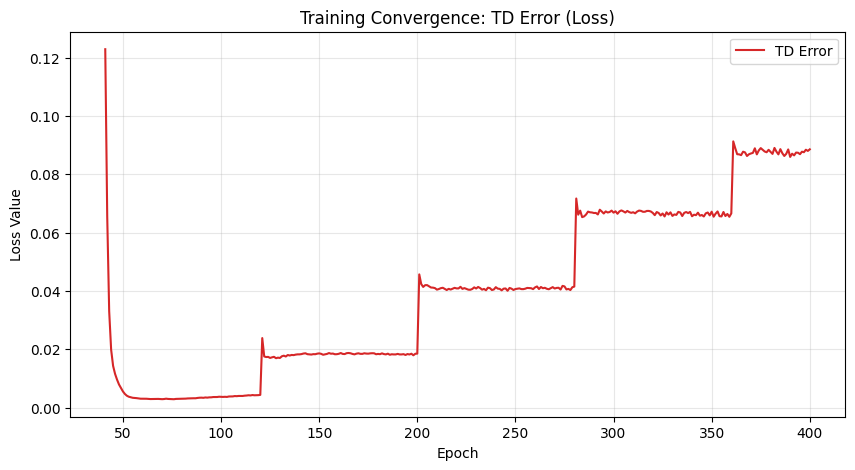

Final recorded loss: 0.088519


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Point to your log folder
log_folder = r"d3rlpy_logs\DQN_online_20260219104031"
loss_path = os.path.join(log_folder, "loss.csv")

epoch_count = 400

# 2. Load and Plot
if os.path.exists(loss_path):
    # Headerless CSVs in d3rlpy often use column 1 for the step and column 2 for the value
    loss_df = pd.read_csv(loss_path, header=None, names=['epoch', 'step', 'loss'])
    loss_df = loss_df.head(epoch_count)
    
    plt.figure(figsize=(10, 5))
    plt.plot(loss_df['epoch'], loss_df['loss'], color='tab:red', label='TD Error')
    
    plt.title('Training Convergence: TD Error (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # Quick Check: Print the final loss value
    print(f"Final recorded loss: {loss_df['loss'].iloc[-1]:.6f}")
else:
    print(f"Error: Could not find loss.csv at {loss_path}")

# Track Performance

In [4]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path

base_env = SalesNegotiationEnv()
env = FlattenObservationWrapper(base_env)

model_version = "DQN_online_20260219104031"
log_folder = f"d3rlpy_logs/{model_version}"

In [5]:

model_nums_lower_bound = 10000
model_nums_upper_bound = 400001

model_nums = range(model_nums_lower_bound, model_nums_upper_bound, 1000)
results_list = []

for model_num in tqdm(model_nums, desc="Evaluating Models"):
    model_path = os.path.join(log_folder, f"model_{model_num}.d3")
    if os.path.exists(model_path):
        dqn = d3rlpy.load_learnable(model_path)
        test_record = evaluate_strategy(dqn, env, 1000)
        
        record_array = np.array(test_record)
        conversion_rate = (record_array > 0).mean()
        average_reward = record_array.mean()
        
        results_list.append({
            "model_num": model_num, 
            "Conversion Rate": conversion_rate, 
            "Average Reward": average_reward
        })

# Create the final DataFrame from the list of dicts
model_test_records = pd.DataFrame(results_list)
model_test_records.to_csv(f'model_test_{model_version}.csv', index=False)

model_test_records_sorted = model_test_records.sort_values(by="Average Reward", ascending=False).reset_index(drop=True)
model_test_records_sorted.head(20)

Evaluating Models: 100%|██████████| 391/391 [10:22<00:00,  1.59s/it]


,model_num,Conversion Rate,Average Reward
0,59000,0.6790,3.8312
1,68000,0.6775,3.8033
2,182000,0.6640,3.7710
3,179000,0.6555,3.7427
4,164000,0.6590,3.7365
5,173000,0.6645,3.7149
6,175000,0.6630,3.7069
7,178000,0.6430,3.7048
8,72000,0.6700,3.7038
9,70000,0.6750,3.6938


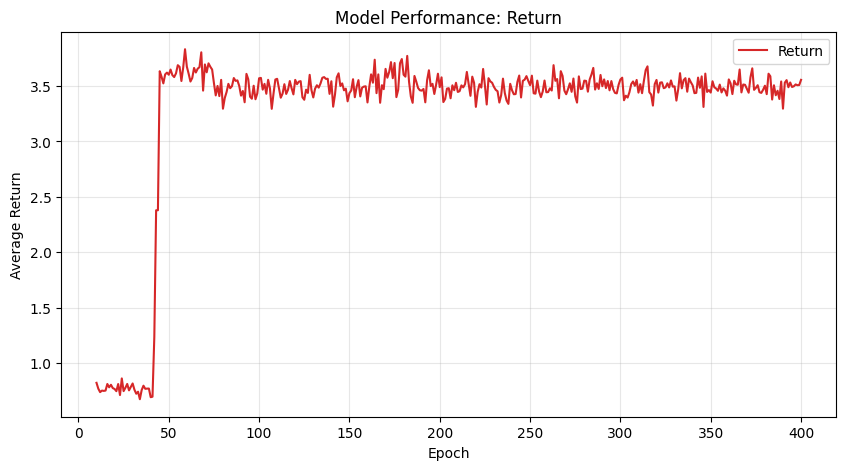

Highest return: 3.831200 at epoch 59


In [ ]:


epoch_count = 500

return_df = model_test_records.head(epoch_count)

plt.figure(figsize=(10, 5))
plt.plot(return_df['model_num']//1000, return_df['Average Reward'], color='tab:red', label='Return')
plt.title('Model Performance: Return')
plt.xlabel('Epoch')
plt.ylabel('Average Return')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Find the row with the highest return
max_row = return_df.loc[return_df['Average Reward'].idxmax()]
max_epoch = int(max_row['model_num']//1000)
max_return = float(max_row['Average Reward'])
print(f"Highest return: {max_return:.6f} at epoch {max_epoch}")



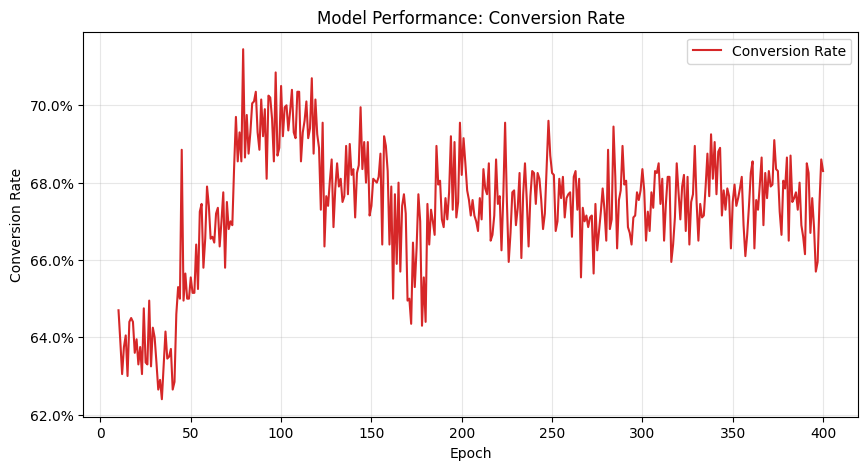

Highest return: 0.714500 at epoch 79


In [19]:
from matplotlib.ticker import PercentFormatter


plt.figure(figsize=(10, 5))
plt.plot(return_df['model_num']//1000, return_df['Conversion Rate']*100, color='tab:red', label='Conversion Rate')
plt.title('Model Performance: Conversion Rate')
plt.xlabel('Epoch')
plt.ylabel('Conversion Rate')
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

max_row = return_df.loc[return_df['Conversion Rate'].idxmax()]
max_epoch = int(max_row['model_num']//1000)
max_return = float(max_row['Conversion Rate'])
print(f"Highest return: {max_return:.6f} at epoch {max_epoch}")


In [25]:
model_num = 100 * 1000
model_path = os.path.join(log_folder, f"model_{model_num}.d3")
test_record = evaluate_strategy(dqn, env, 5000, verbose = True)
record_array = np.array(test_record)
conversion_rate = (record_array > 0).mean()
average_reward = record_array.mean()

print(f"Conversion Rate: {conversion_rate * 100:.2f}%.\nAverage Reward: {average_reward:.6f}.")
DQN_record = {"model_name": "DQN", "average_reward": average_reward, "conversion_rate": conversion_rate}


Evaluating Models: 100%|██████████| 5000/5000 [00:08<00:00, 588.10it/s]


Conversion Rate: 67.66%.
Average Reward: 3.498180.


## Random Stretegy

In [ ]:
evaluation_df = []

,model_name,average_reward,conversion_rate,average_round
0,Random Strategy,-0.213020,0.265300,3.2489
1,Gemini 2.5 Flash,0.567568,0.391892,NaN
2,DQN,3.519200,0.704500,NaN


In [35]:
"""
base_env = SalesNegotiationEnv(max_round=30, p_factor = 2.7)
env = FlattenObservationWrapper(base_env)
"""
import random

test_record = []
round_count_record = []
for _ in range(10000):
    obs, _ = env.reset()
    done = False
    episode_reward = 0
    round_count = 0
    while not done:
        round_count += 1
        if round_count >= 5:
            action = np.random.randint(0,3)
        else:
            action = np.random.randint(0,2)
        if obs[int(5 + obs[0])] == 4 or bool(obs[4]):
            if round_count >= 5 and random.random() < 0.5:
                action = 2
            else:
                action = 0
        obs, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        done = terminated or truncated
    
    test_record.append(episode_reward)
    round_count_record.append(round_count)
    
print(f"Conversion Rate: {np.array(np.array(test_record) > 0).mean()}.")
print(f"Average Reward: {np.array(test_record).mean()}.")
print(f"Average Round: {np.array(round_count_record).mean()}")

evaluation_df.append({"model_name": "Random Strategy", "average_reward": np.array(test_record).mean(), "conversion_rate": np.array(np.array(test_record) > 0).mean(), "average_round": np.array(round_count_record).mean()})

Conversion Rate: 0.2653.
Average Reward: -0.2130199999999998.
Average Round: 3.2489


In [39]:
# gemini record

gemini_record = pd.read_csv("test_result_20260202_100859_gemini25flash.csv")
average_reward_gemini = gemini_record['reward'].mean()
conversion_rate_gemini = gemini_record['reward'].apply(lambda x: x > 0).mean()
evaluation_df.append({"model_name": "Gemini 2.5 Flash", "average_reward": average_reward_gemini, "conversion_rate": conversion_rate_gemini})


In [41]:
import time
time_stamp = time.strftime("%Y%m%d_%H%M%S", time.localtime())

evaluation_df.append(DQN_record)
evaluation_df = pd.DataFrame(evaluation_df)
evaluation_df.to_csv(f"evaluation_{time_stamp}.csv", index=False)


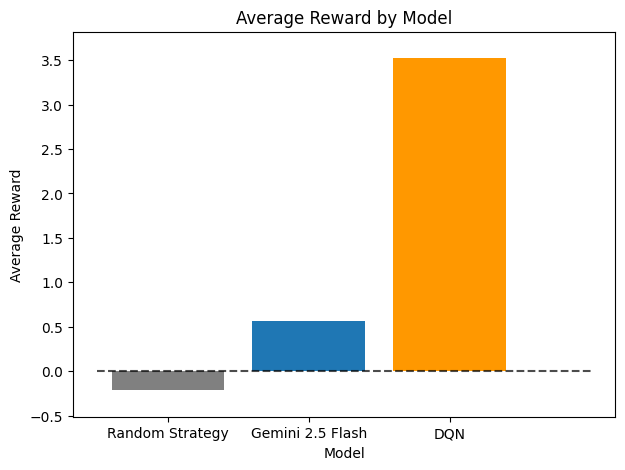

In [42]:
import matplotlib.pyplot as plt
eval_df = pd.read_csv(f"evaluation_{time_stamp}.csv")

model_names = eval_df['model_name']
average_rewards = eval_df['average_reward']

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, average_rewards, color=["#808080", "#1f77b4", "#FF9800"])
plt.ylabel("Average Reward")
plt.xlabel("Model")
plt.hlines(y=0, xmin=-0.5, xmax=len(model_names), color='black', linestyle='--', alpha=0.7)
plt.title("Average Reward by Model")
plt.ylim(min(average_rewards)-0.3, max(average_rewards)+0.3)
plt.show()

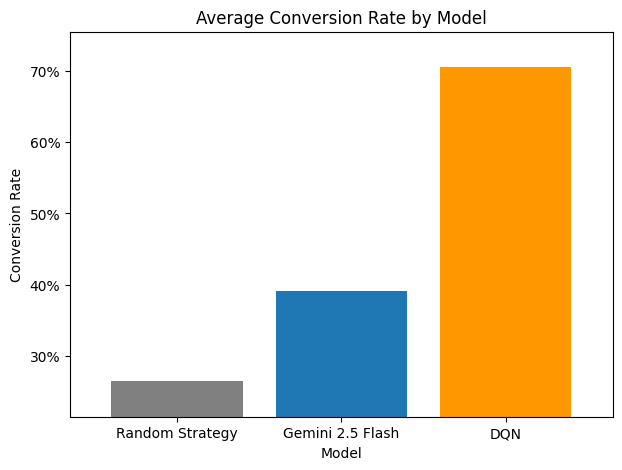

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

model_names = eval_df['model_name']
conversion_rate = eval_df['conversion_rate']

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, conversion_rate, color=["#808080", "#1f77b4", "#FF9800"])
plt.ylabel("Conversion Rate")
plt.xlabel("Model")
plt.hlines(y=0, xmin=-0.5, xmax=len(model_names) - 0.5, color='black', linestyle='--', alpha=0.7)
plt.title("Average Conversion Rate by Model")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.ylim(min(conversion_rate)-0.05, max(conversion_rate)+0.05)
plt.show()